# Windrose Tilt Summaries

Direction and magnitude summaries for AE/CE tilt vectors.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

import seacofs_tilt_tools as tilt

paths = tilt.Paths()
grid = tilt.load_grid(paths.grid, paths.z_r)
df_eddies, df_tilt = tilt.load_tilt_tables(paths, add_regions=True, grid=grid)
mag_bins = [0, 10, 20, 30, 40, np.inf]
# mag_bins = [0, 20, 40, 60, 80, np.inf]
df_eddies.head()


,Eddy,Day,Cyc,lon,lat,ic,jc,xc,yc,w,...,Rc,psi0,AR,R,Age,Date,fname,TiltDis,TiltDir,Region
0,1,1462,CE,152.716333,-38.866383,171,26,474.560686,127.605656,-0.000032,...,29.449052,7.225911,1.973172,20.004291,26,1994-01-02,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,NaN,NaN,D1
1,1,1463,CE,152.836206,-38.814279,173,28,482.821993,136.635735,-0.000041,...,29.449052,7.225911,1.859668,18.906549,26,1994-01-03,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,NaN,NaN,D1
2,1,1464,CE,152.905198,-38.816261,175,28,488.606048,138.480541,-0.000035,...,32.090160,7.712683,1.745185,20.859920,26,1994-01-04,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,32.108725,86.935593,D1
3,1,1465,CE,152.719389,-38.902070,171,25,475.960098,123.953440,-0.000020,...,34.827275,8.275696,1.433213,18.674495,26,1994-01-05,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,18.724015,115.637402,D1
4,1,1466,CE,152.753007,-38.935135,172,25,479.803789,121.483614,-0.000026,...,37.564389,8.838709,1.140614,21.564028,26,1994-01-06,/srv/scratch/z3533156/26year_BRAN2020/outer_av...,11.617020,160.125464,D1


In [2]:
# vertical = tilt.load_vert(paths)
# from scipy.spatial.distance import pdist
# spread = (vertical.groupby(['Eddy','Day'])
#           .apply(lambda x: pdist(x[['xc','yc']].dropna()).max()
#                  if x[['xc','yc']].dropna().shape[0] > 1 else np.nan)
#           .rename('TiltMaxSpread').reset_index())

# df_eddies = df_eddies.merge(spread, on=['Eddy','Day'], how='left')
# df_eddies['TiltDis'] = df_eddies['TiltMaxSpread']

2081.0
2025.0


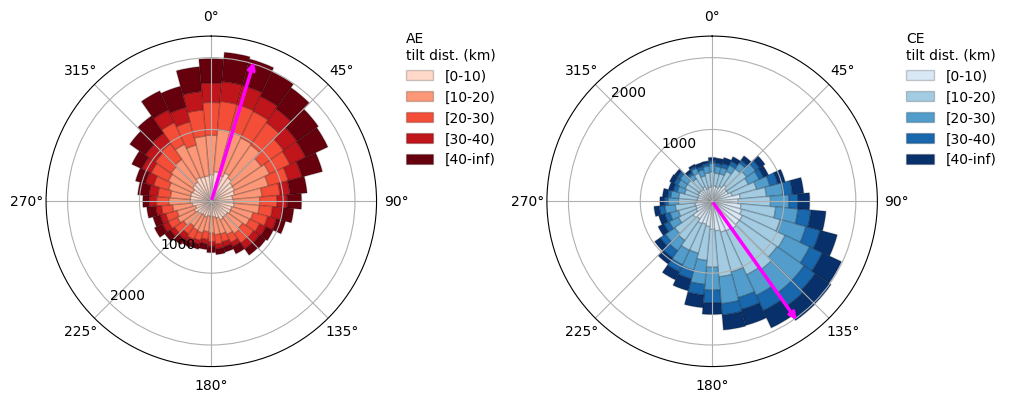

In [3]:
fig, axs = plt.subplots(1, 2, figsize=(10, 5), subplot_kw={'projection':'polar'}, constrained_layout=True)

for ax, cyc, colors in zip(axs, ['AE','CE'], [plt.cm.Reds(np.linspace(.15,1,len(mag_bins)-1)), plt.cm.Blues(np.linspace(.15,1,len(mag_bins)-1))]):
    df = df_eddies[(df_eddies.Cyc==cyc) & df_eddies.Region.isin(['U1','U2','D1','D2'])].dropna(subset=['TiltDir','TiltDis'])
    tilt.plot_windrose(ax, df, title='', mag_bins=mag_bins, colors=colors, step=1000, rlim=2300)

    th = np.deg2rad(df.TiltDir)
    th = np.arctan2(np.mean(np.sin(th)), np.mean(np.cos(th)))
    ax.annotate('', xy=(th,.9*ax.get_ylim()[1]), xytext=(th,0),
                arrowprops=dict(arrowstyle='->', lw=2.5, color='magenta'))

    ax.legend(title=f'{cyc}\ntilt dist. (km)', loc='upper left', bbox_to_anchor=(1.05,1.05), frameon=False)

plt.show()

2081.0
AE mean tilt dir 17, tilt dis 24 km
2025.0
CE mean tilt dir 145, tilt dis 21 km


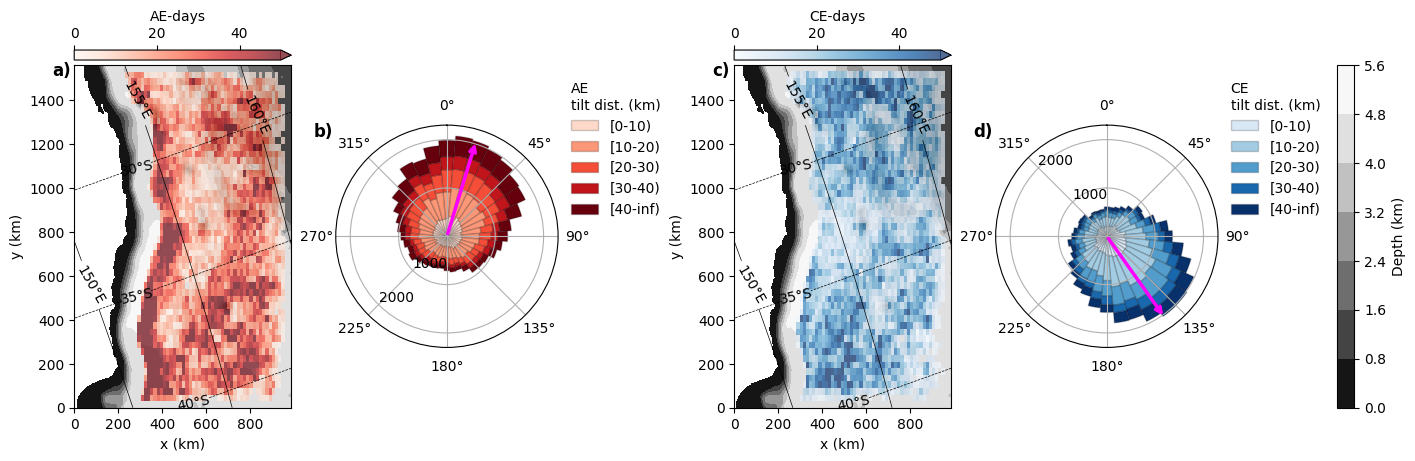

In [4]:
fig, axs = tilt.plot_tilt_summary(df_eddies[df_eddies.Region.isin(['U1','U2','D1','D2'])].copy(), cbar_lims={'AE':(0,50), 'CE':(0,50)},
                                  grid=grid, mag_bins=[0,10,20,30,40,np.inf], density=True, step=1000, rlim=2300)


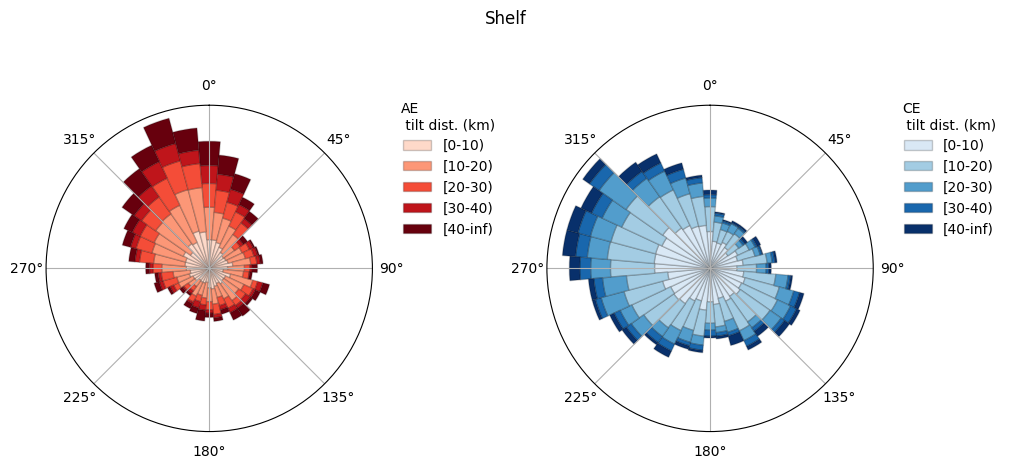

In [5]:
fig, axs = plt.subplots(1, 2, figsize=(10, 5), subplot_kw={"projection": "polar"}, constrained_layout=True)
for ax, cyc, colors in zip(axs, ["AE", "CE"], [plt.cm.Reds(np.linspace(0.15, 1, len(mag_bins) - 1)), plt.cm.Blues(np.linspace(0.15, 1, len(mag_bins) - 1))]):
    subset = df_eddies.loc[df_eddies.Cyc == cyc].dropna(subset=["TiltDir", "TiltDis"])
    subset = subset[subset.Region.isin(['S1','S2'])]
    tilt.plot_windrose(ax, subset, title='', mag_bins=mag_bins, colors=colors)
    ax.legend(title=f"{cyc}\n tilt dist. (km)", loc="upper left", bbox_to_anchor=(1.05, 1.05), frameon=False)
    ax.set_rticks([])
plt.suptitle('Shelf')
plt.show()

## Regional rose plot

This uses the shared `rose_plot` helper so the same regional windrose layout can be reused in other notebooks.


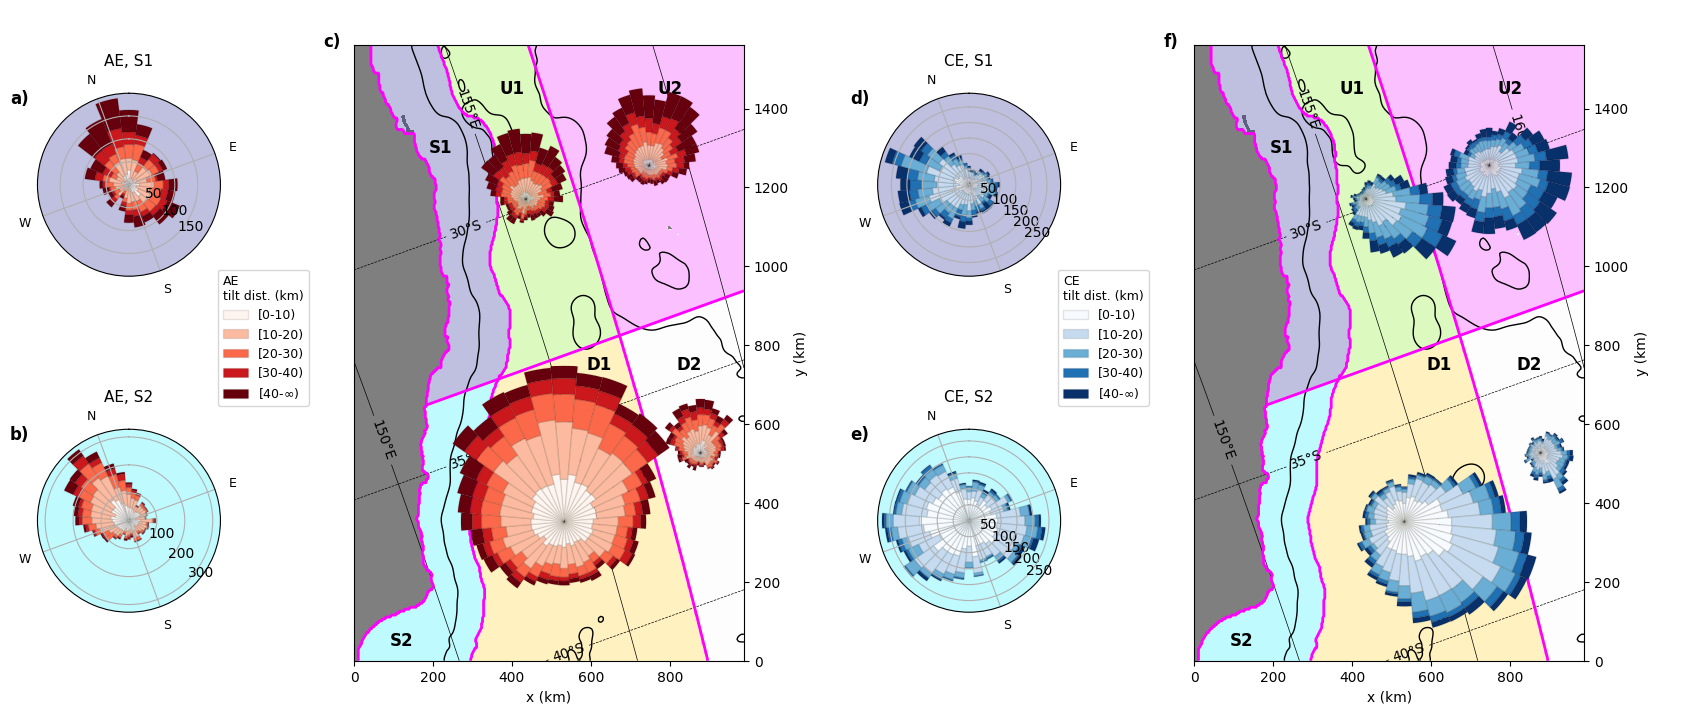

In [6]:
fig, rose = tilt.rose_plot(
    df_eddies,
    grid,
    mag="TiltDis",
    theta="TiltDir",
    mag_bins=mag_bins,
    frac=2.4,
    direction_offset=-20,
    shelf_offset=80,
    legend_title="tilt dist. (km)",
)


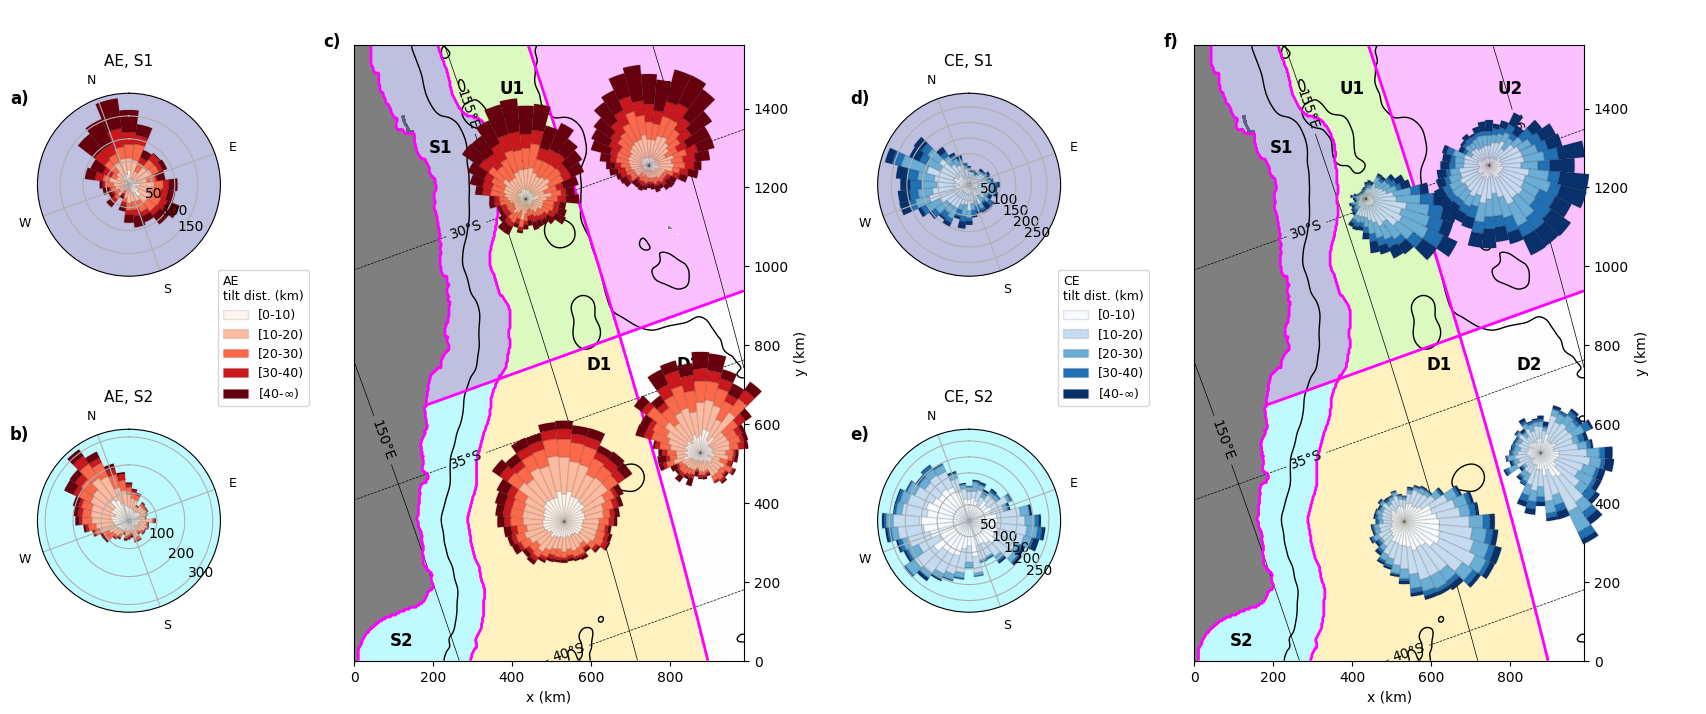

In [7]:
fig, rose = tilt.rose_plot(
    df_eddies,
    grid,
    mag="TiltDis",
    theta="TiltDir",
    mag_bins=mag_bins,
    frac=2.4,
    direction_offset=-20,
    shelf_offset=80,
    legend_title="tilt dist. (km)",
    map_norm_factor=600
)

In [8]:
eddy = df_eddies[df_eddies.Age==df_eddies.Age.max()].iloc[0].Eddy
vertical_df = tilt.load_vert(paths, dic_form=False)
df_eddy = vertical_df[vertical_df.Eddy==eddy].copy()
# plt.plot(

/scratch/pbs.9377399.kman.restech.unsw.edu.au/ipykernel_1245115/518635099.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title=f"{cyc}\n tilt dist. (km)", loc="upper left", bbox_to_anchor=(1.05, 1.05), frameon=False)


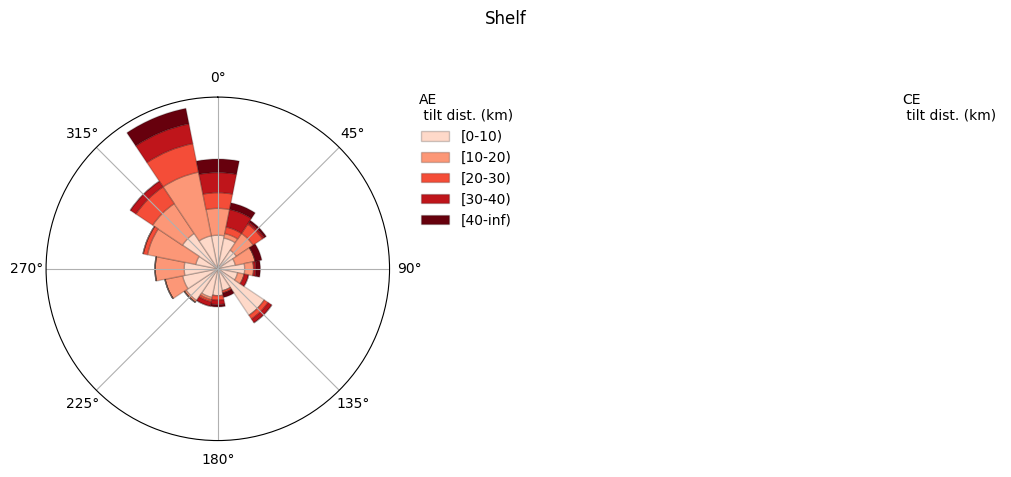

In [9]:
fig, axs = plt.subplots(1, 2, figsize=(10, 5), subplot_kw={"projection": "polar"}, constrained_layout=True)
for ax, cyc, colors in zip(axs, ["AE", "CE"], [plt.cm.Reds(np.linspace(0.15, 1, len(mag_bins) - 1)), plt.cm.Blues(np.linspace(0.15, 1, len(mag_bins) - 1))]):
    subset = df_eddies.loc[(df_eddies.Eddy==eddy)&(df_eddies.Cyc==cyc)].dropna(subset=["TiltDir", "TiltDis"])
    tilt.plot_windrose(ax, subset, title='', mag_bins=mag_bins, colors=colors)
    ax.legend(title=f"{cyc}\n tilt dist. (km)", loc="upper left", bbox_to_anchor=(1.05, 1.05), frameon=False)
    ax.set_rticks([])
plt.suptitle('Shelf')
plt.show()